In [2]:
import zipfile
import os
import pandas as pd

zip_path = "/content/archive (1).zip" # Corrected path to the zip file
extract_path = "extracted_files"

# Extract ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Read all CSV files
dataframes = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_path = os.path.join(root, file)

            df = pd.read_csv(csv_path)
            dataframes.append(df)

print("Total CSV files loaded:", len(dataframes))

Total CSV files loaded: 2


In [6]:
# The previous cell already extracted the CSVs and loaded them into 'dataframes'.
# You can access individual dataframes from this list. For example, to see the first one:
df = dataframes[0] # Assuming you want to inspect the first dataframe in the list

# Display the first 5 rows
print(df.head())

   Unnamed: 0                                      description_x  \
0           0                     first trust dow jones internet   
1           1                schwab intl large company index etf   
2           2                       vanguard small cap index adm   
3           3  duke energy corp new com new isin #us4 sedol #...   
4           4                                   visa inc class a   

                                       description_y ticker_x ticker_y  \
0                        first trust dj internet idx      FDN      FDN   
1  schwab strategic tr fundamental intl large co ...     FNDF     FNDF   
2                 vanguard small-cap index fund inst    VSMAX    VSCIX   
3  duke energy corp new com new isin #us26441c204...      DUK      DUK   
4                                          visa inc.        V        V   

   same_security  
0           True  
1           True  
2          False  
3           True  
4           True  


In [8]:
# Display original text
print("Original Text:")
print(df['description_x'].head()) # Changed 'text' to 'description_x'

# Convert text to lowercase
df['text_lower'] = df['description_x'].str.lower() # Changed 'text' to 'description_x'

# Display converted text
print("\nLowercase Text:")
print(df['text_lower'].head())

Original Text:
0                       first trust dow jones internet
1                  schwab intl large company index etf
2                         vanguard small cap index adm
3    duke energy corp new com new isin #us4 sedol #...
4                                     visa inc class a
Name: description_x, dtype: object

Lowercase Text:
0                       first trust dow jones internet
1                  schwab intl large company index etf
2                         vanguard small cap index adm
3    duke energy corp new com new isin #us4 sedol #...
4                                     visa inc class a
Name: text_lower, dtype: object


In [9]:
print(df.columns)

Index(['Unnamed: 0', 'description_x', 'description_y', 'ticker_x', 'ticker_y',
       'same_security', 'text_lower'],
      dtype='object')


In [12]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab') # Download 'punkt_tab' resource

df['tokens'] = df['text_lower'].apply(lambda x: word_tokenize(str(x))) # Changed 'text' to 'text_lower'

# Display tokens for 5 samples
for i in range(5):
    print(f"Sample {i+1}:")
    print(df['tokens'].iloc[i])
    print()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


Sample 1:
['first', 'trust', 'dow', 'jones', 'internet']

Sample 2:
['schwab', 'intl', 'large', 'company', 'index', 'etf']

Sample 3:
['vanguard', 'small', 'cap', 'index', 'adm']

Sample 4:
['duke', 'energy', 'corp', 'new', 'com', 'new', 'isin', '#', 'us4', 'sedol', '#', 'b7jzsk0']

Sample 5:
['visa', 'inc', 'class', 'a']



[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [14]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# Load English stopwords
stop_words = set(stopwords.words('english'))

# Remove stopwords
df['text_no_stopwords'] = df['text_lower'].apply( # Changed 'text' to 'text_lower'
    lambda x: ' '.join(
        [word for word in str(x).split() if word.lower() not in stop_words]
    )
)

# Show before and after for 5 samples
for i in range(5):
    print(f"Sample {i+1}")
    print("Before :", df['text_lower'].iloc[i]) # Changed 'text' to 'text_lower'
    print("After  :", df['text_no_stopwords'].iloc[i])
    print()

Sample 1
Before : first trust dow jones internet
After  : first trust dow jones internet

Sample 2
Before : schwab intl large company index etf
After  : schwab intl large company index etf

Sample 3
Before : vanguard small cap index adm
After  : vanguard small cap index adm

Sample 4
Before : duke energy corp new com new isin #us4 sedol #b7jzsk0
After  : duke energy corp new com new isin #us4 sedol #b7jzsk0

Sample 5
Before : visa inc class a
After  : visa inc class



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
print(df.columns)


Index(['Unnamed: 0', 'description_x', 'description_y', 'ticker_x', 'ticker_y',
       'same_security', 'text_lower', 'tokens', 'text_no_stopwords'],
      dtype='object')


In [17]:
import nltk
from nltk.stem import PorterStemmer

nltk.download('punkt')

ps = PorterStemmer()

# Apply stemming
df['stemmed_text'] = df['text_no_stopwords'].apply( # Changed 'text' to 'text_no_stopwords'
    lambda x: ' '.join([ps.stem(word) for word in str(x).split()])
)

# Display 10 samples
for i in range(10):
    print(f"Sample {i+1}")
    print("Original :", df['text_no_stopwords'].iloc[i]) # Changed 'text' to 'text_no_stopwords'
    print("Stemmed  :", df['stemmed_text'].iloc[i])
    print()

Sample 1
Original : first trust dow jones internet
Stemmed  : first trust dow jone internet

Sample 2
Original : schwab intl large company index etf
Stemmed  : schwab intl larg compani index etf

Sample 3
Original : vanguard small cap index adm
Stemmed  : vanguard small cap index adm

Sample 4
Original : duke energy corp new com new isin #us4 sedol #b7jzsk0
Stemmed  : duke energi corp new com new isin #us4 sedol #b7jzsk0

Sample 5
Original : visa inc class
Stemmed  : visa inc class

Sample 6
Original : ford motor co new div: 0.600
Stemmed  : ford motor co new div: 0.600

Sample 7
Original : united states steel corp
Stemmed  : unit state steel corp

Sample 8
Original : vanguard total international bond index etf
Stemmed  : vanguard total intern bond index etf

Sample 9
Original : schwab strategic tr us sml c
Stemmed  : schwab strateg tr us sml c

Sample 10
Original : mfs value fd cl
Stemmed  : mf valu fd cl



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [19]:

import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer

nltk.download('wordnet')
nltk.download('omw-1.4')

ps = PorterStemmer()
lemmatizer = WordNetLemmatizer()

df['stemmed_text'] = df['text_no_stopwords'].apply(
    lambda x: ' '.join([ps.stem(word) for word in str(x).split()])
)

df['lemmatized_text'] = df['text_no_stopwords'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(word) for word in str(x).split()])
)

for i in range(10):
    print(f"Sample {i+1}")
    print("Original   :", df['text_no_stopwords'].iloc[i])
    print("Stemmed    :", df['stemmed_text'].iloc[i])
    print("Lemmatized :", df['lemmatized_text'].iloc[i])
    print()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Sample 1
Original   : first trust dow jones internet
Stemmed    : first trust dow jone internet
Lemmatized : first trust dow jones internet

Sample 2
Original   : schwab intl large company index etf
Stemmed    : schwab intl larg compani index etf
Lemmatized : schwab intl large company index etf

Sample 3
Original   : vanguard small cap index adm
Stemmed    : vanguard small cap index adm
Lemmatized : vanguard small cap index adm

Sample 4
Original   : duke energy corp new com new isin #us4 sedol #b7jzsk0
Stemmed    : duke energi corp new com new isin #us4 sedol #b7jzsk0
Lemmatized : duke energy corp new com new isin #us4 sedol #b7jzsk0

Sample 5
Original   : visa inc class
Stemmed    : visa inc class
Lemmatized : visa inc class

Sample 6
Original   : ford motor co new div: 0.600
Stemmed    : ford motor co new div: 0.600
Lemmatized : ford motor co new div: 0.600

Sample 7
Original   : united states steel corp
Stemmed    : unit state steel corp
Lemmatized : united state steel corp

Sample

In [20]:
from sklearn.feature_extraction.text import CountVectorizer

# Create BoW model
vectorizer = CountVectorizer()

# Fit and transform the text data
X = vectorizer.fit_transform(df['text_no_stopwords'].astype(str))

# Vocabulary
print("Vocabulary:")
print(vectorizer.vocabulary_)

# Feature Names
print("\nFeature Names:")
print(vectorizer.get_feature_names_out())

# BoW Matrix
print("\nBoW Matrix:")
print(X.toarray())

# Shape of Matrix
print("\nShape:")
print(X.shape)

Vocabulary:
{'first': 525, 'trust': 1274, 'dow': 424, 'jones': 728, 'internet': 688, 'schwab': 1090, 'intl': 690, 'large': 743, 'company': 353, 'index': 653, 'etf': 481, 'vanguard': 1324, 'small': 1139, 'cap': 286, 'adm': 112, 'duke': 434, 'energy': 462, 'corp': 369, 'new': 889, 'com': 340, 'isin': 716, 'us4': 1292, 'sedol': 1106, 'b7jzsk0': 208, 'visa': 1342, 'inc': 645, 'class': 323, 'ford': 535, 'motor': 857, 'co': 331, 'div': 413, '600': 87, 'united': 1285, 'states': 1188, 'steel': 1189, 'total': 1252, 'international': 686, 'bond': 250, 'strategic': 1199, 'tr': 1256, 'us': 1287, 'sml': 1144, 'mfs': 830, 'value': 1318, 'fd': 512, 'cl': 321, 'oppenheimer': 928, 'dev': 398, 'markets': 799, 'genomic': 564, 'health': 613, 'spdr': 1163, 'barclays': 216, 'kraft': 740, 'heinz': 616, 'market': 798, 'fund': 549, 'admiral': 115, 'shares': 1121, 'intermediate': 683, 'term': 1233, 'investment': 697, 'grade': 583, 'investor': 700, 'baidu': 209, 'spon': 1169, 'adr': 116, 'novartis': 902, 'ag': 12

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF model
vectorizer = TfidfVectorizer()

# Fit and transform the text data
X_tfidf = vectorizer.fit_transform(df['text_no_stopwords'].astype(str))

# Vocabulary
print("Vocabulary:")
print(vectorizer.vocabulary_)

# Feature Names
print("\nFeature Names:")
print(vectorizer.get_feature_names_out())

# TF-IDF Matrix
print("\nTF-IDF Matrix:")
print(X_tfidf.toarray())

# Shape of Matrix
print("\nShape:")
print(X_tfidf.shape)

Vocabulary:
{'first': 525, 'trust': 1274, 'dow': 424, 'jones': 728, 'internet': 688, 'schwab': 1090, 'intl': 690, 'large': 743, 'company': 353, 'index': 653, 'etf': 481, 'vanguard': 1324, 'small': 1139, 'cap': 286, 'adm': 112, 'duke': 434, 'energy': 462, 'corp': 369, 'new': 889, 'com': 340, 'isin': 716, 'us4': 1292, 'sedol': 1106, 'b7jzsk0': 208, 'visa': 1342, 'inc': 645, 'class': 323, 'ford': 535, 'motor': 857, 'co': 331, 'div': 413, '600': 87, 'united': 1285, 'states': 1188, 'steel': 1189, 'total': 1252, 'international': 686, 'bond': 250, 'strategic': 1199, 'tr': 1256, 'us': 1287, 'sml': 1144, 'mfs': 830, 'value': 1318, 'fd': 512, 'cl': 321, 'oppenheimer': 928, 'dev': 398, 'markets': 799, 'genomic': 564, 'health': 613, 'spdr': 1163, 'barclays': 216, 'kraft': 740, 'heinz': 616, 'market': 798, 'fund': 549, 'admiral': 115, 'shares': 1121, 'intermediate': 683, 'term': 1233, 'investment': 697, 'grade': 583, 'investor': 700, 'baidu': 209, 'spon': 1169, 'adr': 116, 'novartis': 902, 'ag': 12

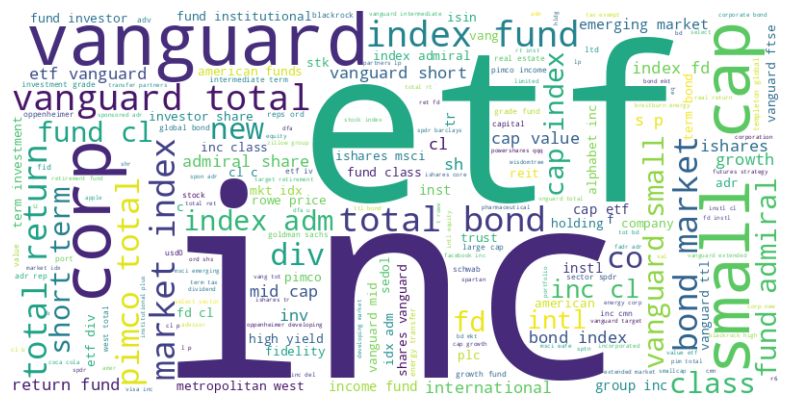

In [25]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all text into one string
text = " ".join(df['text_no_stopwords'].astype(str))

# Generate Word Cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()